# Bose-Einstein condensation

This notebook is part of the computational resources for the Statistical Physics course at École Polytechnique. To return to the main repository, follow this link: [https://github.com/cossio/StatPhysCompX](https://github.com/cossio/StatPhysCompX).

In this notebook we simulate an ideal Bose gas to observe Bose-Einstein Condensation (BEC).

Unlike classical particles, identical quantum particles are **indistinguishable**. For bosons (particles with integer spin), any number of them can occupy the same quantum state.

- **Bose-Einstein Statistics**: At a given temperature, the particles distribute themselves among the available energy levels ($\epsilon_0,\epsilon_1,\epsilon_2,\dots$).
- **Bose-Einstein Condensation**: Below a certain critical temperature ($T_c$), a macroscopic fraction of the particles accumulates in the ground state ($\epsilon_0$).

Instead of tracking individual particles, our simulation tracks the **occupation numbers** $(n_0, n_1, n_2, \dots)$, where $n_i$ is the number of particles in energy level $\epsilon_i$. The total number of particles is fixed: $\sum_i n_i = N$.

## Monte Carlo method and acceptance criterion

We sample from the canonical ensemble at fixed $N$ and temperature $T$. The probability of a configuration $\{n_i\}$ depends on whether particles are **distinguishable** (classical / Maxwell-Boltzmann) or **indistinguishable** (bosons).

### Indistinguishable bosons (Bose-Einstein)

For indistinguishable bosons in non-degenerate energy levels, each set of occupation numbers corresponds to exactly **one** microstate. The canonical probability is simply:

$$P_{\text{BE}}(\{n_i\}) \propto \exp\!\left(-\frac{1}{T}\sum_i n_i \epsilon_i\right)$$

Our Monte Carlo move proposes to transfer one particle from a randomly chosen level $i$ to another randomly chosen level $j$. Since the proposal is **symmetric** (we pick $(i,j)$ and $(j,i)$ with equal probability), the Metropolis acceptance ratio is:

$$a_{\text{BE}} = \min\!\left(1,\; e^{-\Delta E / T}\right) \quad \text{where } \Delta E = \epsilon_j - \epsilon_i$$

### Distinguishable particles (Maxwell-Boltzmann)

For distinguishable (classical) particles, the set of occupation numbers $\{n_i\}$ corresponds to $\frac{N!}{\prod_i n_i!}$ microstates (the multinomial coefficient counting which particle goes where). The canonical probability becomes:

$$P_{\text{MB}}(\{n_i\}) \propto \frac{N!}{\prod_i n_i!} \exp\!\left(-\frac{1}{T}\sum_i n_i \epsilon_i\right)$$

Moving one particle from level $i$ to level $j$ changes the multinomial factor by $n_i / (n_j + 1)$. With the same symmetric proposal, the acceptance ratio becomes:

$$a_{\text{MB}} = \min\!\left(1,\; \frac{n_i}{n_j+1}\, e^{-\Delta E / T}\right)$$

The extra factor $n_i/(n_j+1)$ penalizes moves that create very unequal occupations — distinguishable particles "prefer" to spread out (higher entropy from the multinomial). Bosons have no such penalty.

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit
from scipy.special import zeta

In [44]:
N = 1000        # Total number of particles
M = 100         # Number of energy levels
n_steps = 50_000_000  # Monte Carlo steps

# Equally-spaced energy levels: epsilon_i = i  (in units of the level spacing)
energies = np.arange(M, dtype=np.float64)

In [45]:
@njit
def run_bec_simulation(N, M, energies, T, n_steps):
    """
    Monte Carlo simulation sampling the Bose-Einstein canonical ensemble.
    
    Acceptance criterion: min(1, exp(-dE/T)).
    No occupation-number prefactor, because for indistinguishable bosons
    each set of occupation numbers {n_i} is a single microstate.
    """
    occupation = np.zeros(M, dtype=np.int64)
    occupation[0] = N  # start with all particles in the ground state

    for step in range(n_steps):
        # Propose: move one particle from level i to level j
        i = np.random.randint(0, M)
        j = np.random.randint(0, M)
        if i == j:
            continue
        if occupation[i] == 0:
            continue  # no particle to move

        dE = energies[j] - energies[i]

        # Metropolis acceptance: symmetric proposal -> ratio is just the Boltzmann factor
        if dE <= 0.0 or np.random.random() < np.exp(-dE / T):
            occupation[i] -= 1
            occupation[j] += 1

    return occupation


@njit
def run_mb_simulation(N, M, energies, T, n_steps):
    """
    Monte Carlo simulation sampling the Maxwell-Boltzmann (classical) canonical ensemble.
    
    Acceptance criterion: min(1, (n_i / (n_j+1)) * exp(-dE/T)).
    The prefactor n_i/(n_j+1) accounts for the multinomial coefficient
    N! / prod(n_k!) that counts how many ways distinguishable particles
    can produce the same occupation numbers.
    """
    occupation = np.zeros(M, dtype=np.int64)
    occupation[0] = N

    for step in range(n_steps):
        i = np.random.randint(0, M)
        j = np.random.randint(0, M)
        if i == j:
            continue
        if occupation[i] == 0:
            continue

        dE = energies[j] - energies[i]
        ni = occupation[i]
        nj = occupation[j]

        # Classical acceptance: includes the multinomial ratio
        acceptance_ratio = np.exp(-dE / T) * (ni / (nj + 1.0))
        if np.random.random() < acceptance_ratio:
            occupation[i] -= 1
            occupation[j] += 1

    return occupation

In [46]:
# Warm up numba JIT (first call triggers compilation)
_ = run_bec_simulation(10, 5, np.arange(5, dtype=np.float64), 1.0, 100)
_ = run_mb_simulation(10, 5, np.arange(5, dtype=np.float64), 1.0, 100)

## Non-degenerate levels: Bose-Einstein vs Maxwell-Boltzmann

We first compare the two statistics on a simple system with $M = 100$ non-degenerate, equally-spaced energy levels $\epsilon_i = i$. We run the simulation at three temperatures.

In [47]:
temperatures = [2.0, 10.0, 50.0]

results_be = {}
results_mb = {}
for T in temperatures:
    print(f"T = {T}: running BE...", end=" ")
    results_be[T] = run_bec_simulation(N, M, energies, T, n_steps)
    print("MB...", end=" ")
    results_mb[T] = run_mb_simulation(N, M, energies, T, n_steps)
    print("done.")

T = 2.0: running BE... MB... done.
T = 10.0: running BE... MB... done.
T = 50.0: running BE... MB... done.


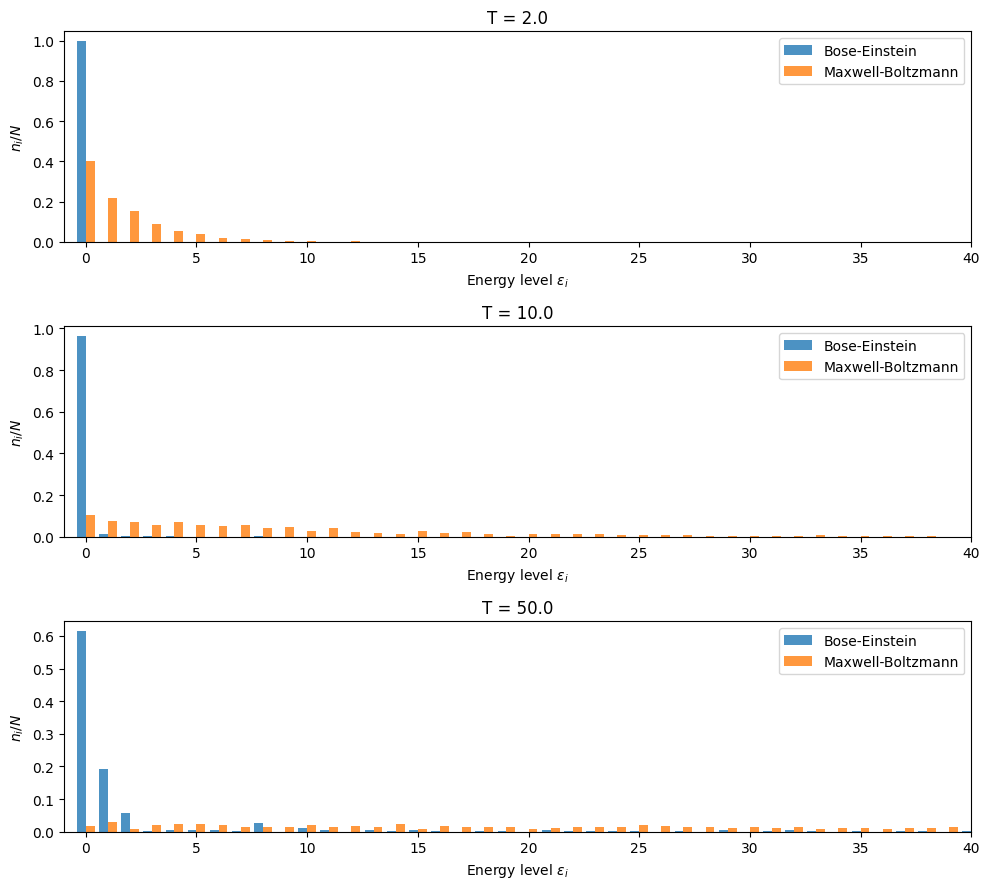

T =   2.0:  ground-state fraction  BE = 0.997,  MB = 0.400
T =  10.0:  ground-state fraction  BE = 0.962,  MB = 0.105
T =  50.0:  ground-state fraction  BE = 0.614,  MB = 0.019


In [48]:
fig, axes = plt.subplots(len(temperatures), 1, figsize=(10, 3 * len(temperatures)))

for ax, T in zip(axes, temperatures):
    ax.bar(energies - 0.2, results_be[T] / N, width=0.4, alpha=0.8, label="Bose-Einstein")
    ax.bar(energies + 0.2, results_mb[T] / N, width=0.4, alpha=0.8, label="Maxwell-Boltzmann")
    ax.set_xlabel("Energy level $\\epsilon_i$")
    ax.set_ylabel("$n_i / N$")
    ax.set_title(f"T = {T}")
    ax.legend()
    ax.set_xlim(-1, 40)

plt.tight_layout()
plt.show()

for T in temperatures:
    be_frac = results_be[T][0] / N
    mb_frac = results_mb[T][0] / N
    print(f"T = {T:5.1f}:  ground-state fraction  BE = {be_frac:.3f},  MB = {mb_frac:.3f}")

At high temperature the two distributions are nearly identical (classical limit). At low temperature, the Bose-Einstein distribution concentrates more particles in the ground state than the Maxwell-Boltzmann distribution. This is because the multinomial factor $n_i/(n_j+1)$ in the classical case penalizes high occupation of any single level.

However, with non-degenerate levels the crossover is smooth — there is no sharp phase transition. To see genuine Bose-Einstein **condensation** as a sharp transition, we need energy levels with increasing degeneracy, as occurs in higher-dimensional systems.

To be a bit more precise,we need a sufficiently rapidly growing density of states / sufficiently large excited-state capacity behavior; degeneracy is one way that happens (e.g., 3D harmonic oscillator below), but not the only way, and non-degenerate spectra can still show macroscopic ground-state occupation depending on confinement and limit.

## 3D isotropic harmonic oscillator: genuine BEC

For a 3D isotropic harmonic oscillator, the energy levels are $\epsilon_n = n\hbar\omega$ (we set $\hbar\omega = 1$), but now level $n$ has a **degeneracy**:

$$g_n = \frac{(n+1)(n+2)}{2}$$

which counts the number of ways to write $n = n_x + n_y + n_z$ with $n_x, n_y, n_z \geq 0$.

We can still work with occupation numbers per energy level, $n_i$ = total number of particles with energy $\epsilon_i$. These $n_i$ particles are distributed among the $g_i$ degenerate sub-states of that level. For indistinguishable bosons, the number of ways to distribute $n_i$ bosons among $g_i$ sub-states is:

$$\binom{n_i + g_i - 1}{n_i}$$

The canonical probability of an occupation-number configuration $\{n_i\}$ is therefore:

$$P(\{n_i\}) \propto \prod_i \binom{n_i + g_i - 1}{n_i} \, e^{-n_i \epsilon_i / T}$$

Moving one particle from level $i$ to level $j$, the ratio of the binomial factors gives:

$$\frac{\binom{n_i - 1 + g_i - 1}{n_i - 1}}{\binom{n_i + g_i - 1}{n_i}} = \frac{n_i}{n_i + g_i - 1}$$

$$\frac{\binom{n_j + 1 + g_j - 1}{n_j + 1}}{\binom{n_j + g_j - 1}{n_j}} = \frac{n_j + g_j}{n_j + 1}$$

The Metropolis acceptance ratio becomes:

$$a = \min\!\left(1,\; \frac{n_i}{n_i + g_i - 1} \cdot \frac{n_j + g_j}{n_j + 1} \cdot e^{-\Delta E / T}\right)$$

Note that for $g_i = 1$ (non-degenerate), the prefactor reduces to 1, recovering the simple Boltzmann acceptance. For large degeneracy, the factor $\frac{n_j + g_j}{n_j + 1} \gg 1$ for small $n_j$, which means the algorithm readily populates highly degenerate excited levels — this is what makes BEC a sharp transition.

### Critical temperature

For $N$ bosons in a 3D harmonic trap, the critical temperature is:

$$T_c = \frac{\hbar\omega}{k_B}\left(\frac{N}{\zeta(3)}\right)^{1/3}$$

In our units ($\hbar\omega / k_B = 1$) this gives $T_c = (N / \zeta(3))^{1/3}$.

In [50]:
@njit
def run_bec_3d_simulation(N, M, energies, degeneracies, T, n_steps):
    """
    Monte Carlo simulation of bosons in a 3D harmonic oscillator.
    
    Energy levels have degeneracy g_i, which modifies the acceptance ratio
    via the binomial factor counting how many ways n_i bosons can occupy
    g_i sub-states.
    """
    occupation = np.zeros(M, dtype=np.int64)
    occupation[0] = N  # start condensed

    for step in range(n_steps):
        i = np.random.randint(0, M)
        j = np.random.randint(0, M)
        if i == j:
            continue
        if occupation[i] == 0:
            continue

        ni = occupation[i]
        nj = occupation[j]
        gi = degeneracies[i]
        gj = degeneracies[j]
        dE = energies[j] - energies[i]

        # Acceptance ratio from the binomial degeneracy factors + Boltzmann weight
        ratio = (ni / (ni + gi - 1.0)) * ((nj + gj) / (nj + 1.0)) * np.exp(-dE / T)

        if np.random.random() < ratio:
            occupation[i] -= 1
            occupation[j] += 1

    return occupation

In [51]:
# 3D harmonic oscillator: degeneracy of level n is (n+1)(n+2)/2
degeneracies = np.array([(n + 1) * (n + 2) // 2 for n in range(M)], dtype=np.int64)

# Warm up JIT
_ = run_bec_3d_simulation(10, 5, np.arange(5, dtype=np.float64),
                          np.array([1, 3, 6, 10, 15], dtype=np.int64), 1.0, 100)

In [52]:
# Critical temperature for N bosons in a 3D harmonic trap
T_c = (N / zeta(3))**(1/3)
print(f"N = {N}, predicted T_c = {T_c:.2f}")

N = 1000, predicted T_c = 9.40


In [53]:
# Scan temperatures from well below to well above T_c
T_values = np.linspace(0.5, 2.0 * T_c, 20)

condensate_fractions = []
for T in T_values:
    print(f"  T = {T:.2f} (T/T_c = {T/T_c:.2f})...", end=" ")
    occ = run_bec_3d_simulation(N, M, energies, degeneracies, T, n_steps)
    condensate_fractions.append(occ[0] / N)
    print(f"n_0/N = {occ[0]/N:.3f}")

condensate_fractions = np.array(condensate_fractions)

  T = 0.50 (T/T_c = 0.05)... n_0/N = 1.000
  T = 1.46 (T/T_c = 0.16)... n_0/N = 0.996
  T = 2.43 (T/T_c = 0.26)... n_0/N = 0.972
  T = 3.39 (T/T_c = 0.36)... n_0/N = 0.921
  T = 4.35 (T/T_c = 0.46)... n_0/N = 0.841
  T = 5.32 (T/T_c = 0.57)... n_0/N = 0.724
  T = 6.28 (T/T_c = 0.67)... n_0/N = 0.568
  T = 7.25 (T/T_c = 0.77)... n_0/N = 0.377
  T = 8.21 (T/T_c = 0.87)... n_0/N = 0.182
  T = 9.17 (T/T_c = 0.98)... n_0/N = 0.006
  T = 10.14 (T/T_c = 1.08)... n_0/N = 0.005
  T = 11.10 (T/T_c = 1.18)... n_0/N = 0.000
  T = 12.06 (T/T_c = 1.28)... n_0/N = 0.000
  T = 13.03 (T/T_c = 1.39)... n_0/N = 0.001
  T = 13.99 (T/T_c = 1.49)... n_0/N = 0.000
  T = 14.96 (T/T_c = 1.59)... n_0/N = 0.002
  T = 15.92 (T/T_c = 1.69)... n_0/N = 0.000
  T = 16.88 (T/T_c = 1.80)... n_0/N = 0.000
  T = 17.85 (T/T_c = 1.90)... n_0/N = 0.000
  T = 18.81 (T/T_c = 2.00)... n_0/N = 0.000


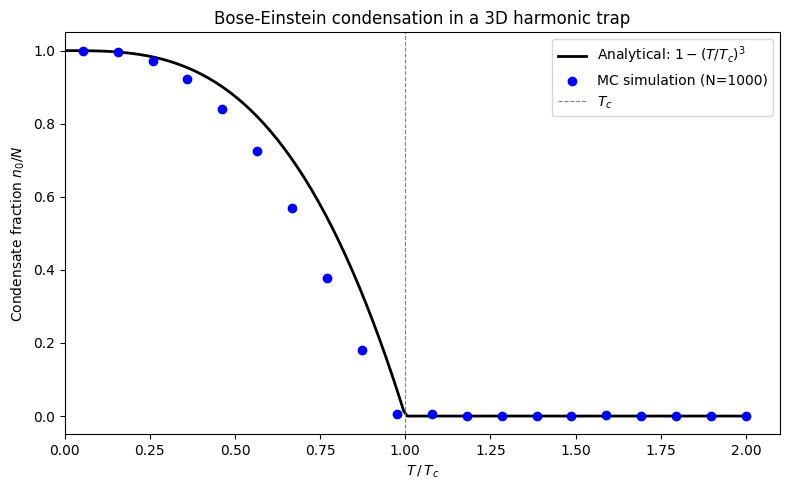

In [54]:
# Analytical prediction for the condensate fraction below T_c:
#   n_0/N = 1 - (T/T_c)^3   for T < T_c
#   n_0/N ~ 0                for T > T_c
T_theory = np.linspace(0.01, 2.0 * T_c, 200)
n0_theory = np.where(T_theory < T_c, 1 - (T_theory / T_c)**3, 0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(T_theory / T_c, n0_theory, "k-", linewidth=2, label=r"Analytical: $1 - (T/T_c)^3$")
ax.scatter(T_values / T_c, condensate_fractions, color="blue", zorder=5,
           label=f"MC simulation (N={N})")
ax.axvline(1.0, color="gray", linestyle="--", linewidth=0.8, label="$T_c$")
ax.set_xlabel(r"$T \, / \, T_c$")
ax.set_ylabel(r"Condensate fraction $n_0 / N$")
ax.set_title("Bose-Einstein condensation in a 3D harmonic trap")
ax.legend()
ax.set_xlim(0, 2.1)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

The simulation reproduces the expected behavior: below $T_c$, a macroscopic fraction of the particles condenses into the ground state. The analytical prediction $n_0/N = 1 - (T/T_c)^3$ (valid in the thermodynamic limit $N \to \infty$) is shown for reference. Finite-$N$ corrections smooth out the transition near $T_c$.